In [ ]:
import numpy as np
import pandas as pd
import torch
from torchvision import datasets
from torchvision import transforms
import torch.nn as nn
from torch.utils.data import DataLoader
import torch.optim as optim
import torchvision.utils as vutils
import matplotlib.pyplot as plt

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [ ]:
transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [ ]:
dataset = datasets.MNIST(root = "", download=True, transform=transform)

In [ ]:
dataLoader = DataLoader(dataset, batch_size=64, shuffle=True)

In [ ]:
class Generator(nn.Module):
    def __init__(self, inputSize=50, outputSize=28*28):
        super().__init__()

        self.Model = nn.Sequential(
            nn.Linear(inputSize, 32),
            nn.ReLU(),

            nn.Linear(32, 64),
            nn.ReLU(),

            nn.Linear(64, 128),
            nn.ReLU(),

            nn.Linear(128, 256),
            nn.ReLU(),

            nn.Linear(256, 512),
            nn.ReLU(),

            nn.Linear(512, 1024),
            nn.ReLU(),

            nn.Linear(1024, outputSize),
            nn.Tanh()
        )

    def forward(self, x):
        x = self.Model(x)
        return x.view(-1, 1, 28, 28)

In [ ]:
class Discriminator(nn.Module):
  def __init__(self, imageSize=28*28):
    super().__init__()

    self.Model = nn.Sequential(

       nn.Linear(imageSize,512),
       nn.ReLU(),

       nn.Linear(512,256),
       nn.ReLU(),

       nn.Linear(256,1),
       nn.Sigmoid(),
    )

  def forward(self, imageSize=28*28):
    imgFlat = imageSize.view(imageSize.size(0), -1)
    return self.Model(imgFlat)

In [ ]:
generator = Generator().to(device)
discriminator = Discriminator().to(device)

In [ ]:
criteria = nn.BCELoss()

In [ ]:
genOptimizer = optim.Adam(generator.parameters(), lr=0.0005, betas=(0.5, 0.999))
disOptimizer = optim.Adam(discriminator.parameters(), lr=0.00003, betas=(0.5, 0.999))

In [ ]:
epochs = 70

Epoch :1/70, Discriminator Loss : 0.6927, Generator Loss : 0.7029


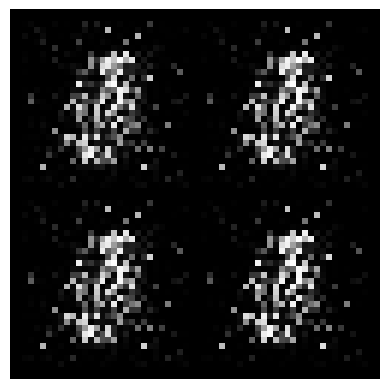

Epoch :2/70, Discriminator Loss : 0.6942, Generator Loss : 0.7410


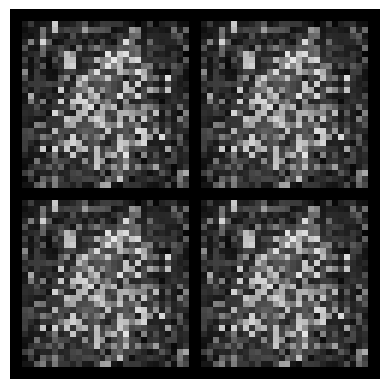

Epoch :3/70, Discriminator Loss : 0.6900, Generator Loss : 0.7590


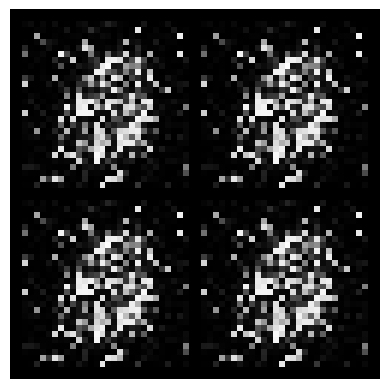

Epoch :4/70, Discriminator Loss : 0.6906, Generator Loss : 0.7716


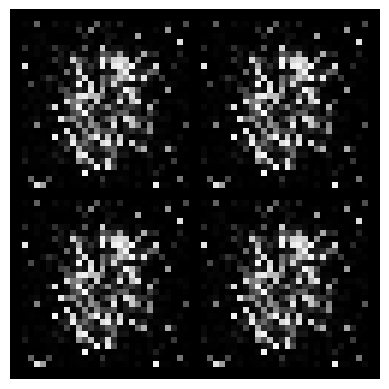

Epoch :5/70, Discriminator Loss : 0.6909, Generator Loss : 0.7674


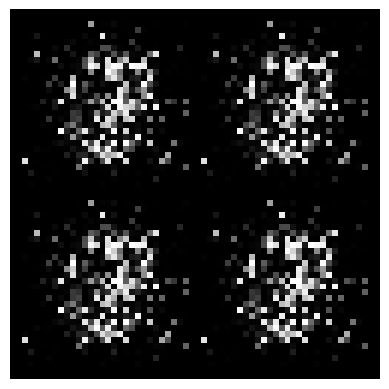

Epoch :6/70, Discriminator Loss : 0.6898, Generator Loss : 0.7745


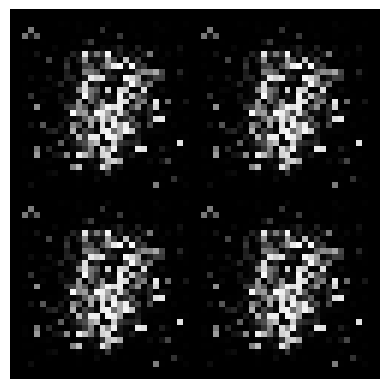

Epoch :7/70, Discriminator Loss : 0.6905, Generator Loss : 0.7747


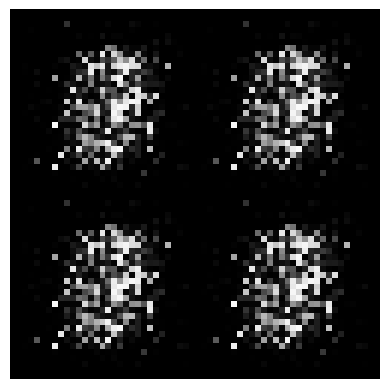

Epoch :8/70, Discriminator Loss : 0.6899, Generator Loss : 0.7791


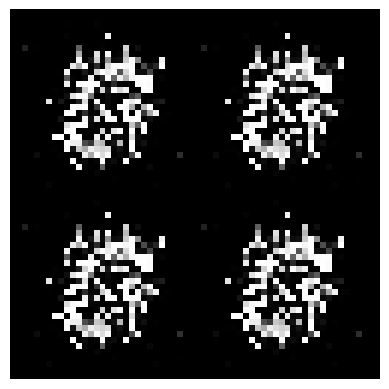

Epoch :9/70, Discriminator Loss : 0.6913, Generator Loss : 0.7783


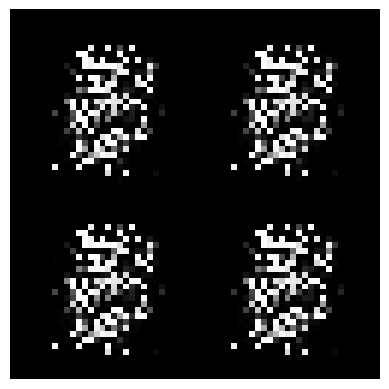

Epoch :10/70, Discriminator Loss : 0.6915, Generator Loss : 0.7526


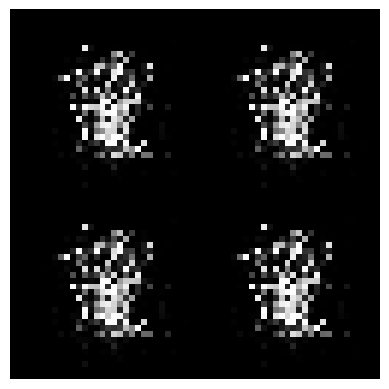

Epoch :11/70, Discriminator Loss : 0.6895, Generator Loss : 0.7869


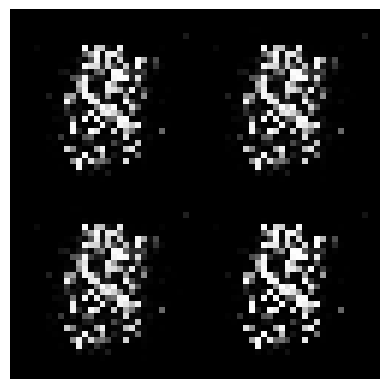

Epoch :12/70, Discriminator Loss : 0.6878, Generator Loss : 0.7823


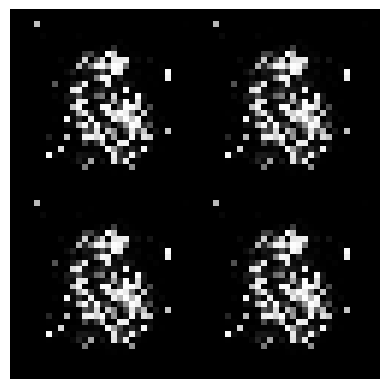

Epoch :13/70, Discriminator Loss : 0.6890, Generator Loss : 0.7825


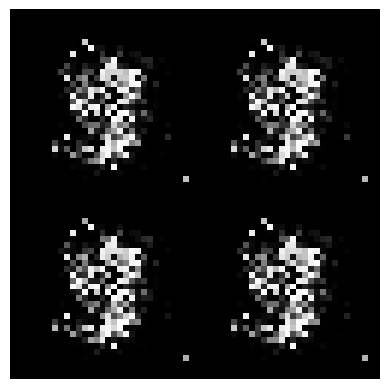

Epoch :14/70, Discriminator Loss : 0.6881, Generator Loss : 0.7907


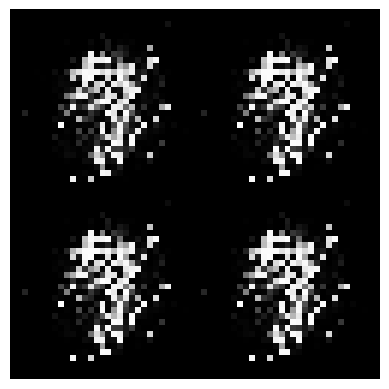

Epoch :15/70, Discriminator Loss : 0.6885, Generator Loss : 0.7863


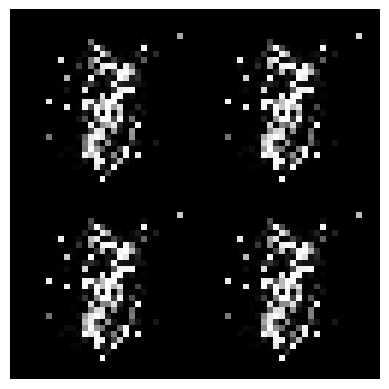

Epoch :16/70, Discriminator Loss : 0.6914, Generator Loss : 0.7698


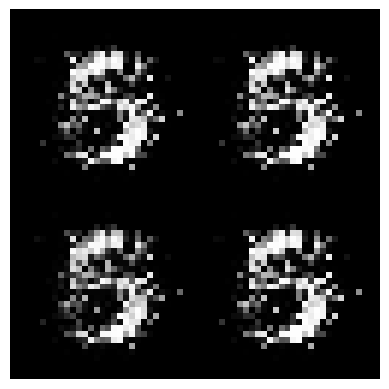

Epoch :17/70, Discriminator Loss : 0.6893, Generator Loss : 0.7987


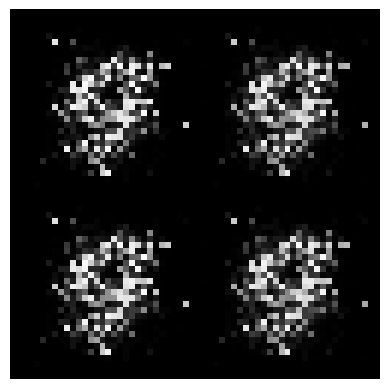

Epoch :18/70, Discriminator Loss : 0.6906, Generator Loss : 0.7473


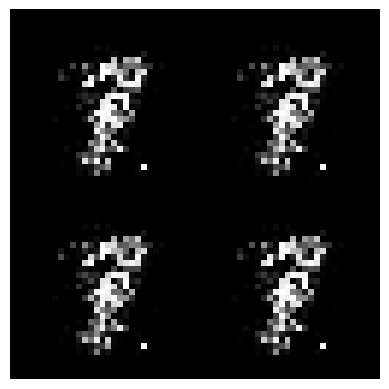

Epoch :19/70, Discriminator Loss : 0.6902, Generator Loss : 0.7697


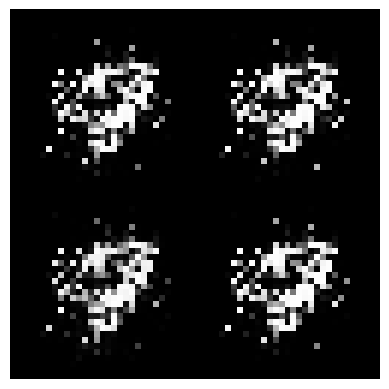

Epoch :20/70, Discriminator Loss : 0.6873, Generator Loss : 0.7893


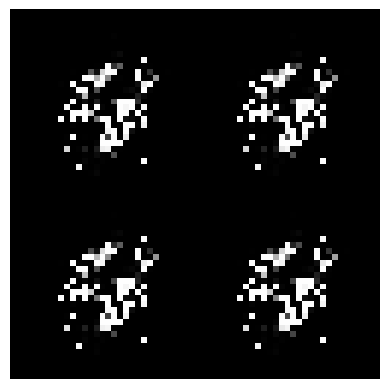

In [ ]:
fixed_z = torch.randn(4, 50).to(device)
for epoch in range(epochs):

    for realImg, _ in dataLoader:
        realImg = realImg.to(device)
        batchSize = realImg.size(0)

        # labels (label smoothing for real)
        fakeLabels = torch.zeros(batchSize, 1).to(device)
        realLabels = torch.full((batchSize, 1), 0.9).to(device)

        # ======================
        # Train Discriminator
        # ======================
        z = torch.randn(batchSize, 50).to(device)
        fakeImg = generator(z)

        realLoss = criteria(discriminator(realImg), realLabels)
        fakeLoss = criteria(discriminator(fakeImg.detach()), fakeLabels)

        totalLoss = (realLoss + fakeLoss)/2

        disOptimizer.zero_grad()
        totalLoss.backward()
        disOptimizer.step()

        # ======================
        # Train Generator
        # ======================
        for _ in range(2):
            z = torch.randn(batchSize, 50).to(device)
            fakeImg = generator(z)

            genLoss = criteria(discriminator(fakeImg), realLabels)

            genOptimizer.zero_grad()
            genLoss.backward()
            genOptimizer.step()

    # ======================
    # Print losses
    # ======================
    print(f"Epoch :{epoch+1}/{epochs}, "
          f"Discriminator Loss : {totalLoss.item():.4f}, "
          f"Generator Loss : {genLoss.item():.4f}")

    with torch.no_grad():
      fake_samples = generator(fixed_z).cpu()

      grid = vutils.make_grid(fake_samples * 0.5 + 0.5, nrow=2)

      plt.imshow(grid.permute(1,2,0))
      plt.axis("off")
      plt.show()

